# Spotify Popularity — Hypothesis Testing

This notebook runs a series of **statistical hypothesis tests** on the Spotify dataset to rigorously validate the patterns observed during EDA. Each test follows the standard structure:

- **H₀ (Null Hypothesis):** no effect or no difference
- **H₁ (Alternative Hypothesis):** an effect or difference exists
- **Significance level:** α = 0.05 — we reject H₀ when p-value < 0.05

---
Tests covered:
1. Normality of popularity scores (Shapiro-Wilk / D'Agostino-Pearson)
2. Explicit vs. Non-Explicit songs — popularity difference (Mann-Whitney U)
3. Major vs. Minor key — popularity difference (Mann-Whitney U)
4. High vs. Low danceability — popularity difference (Mann-Whitney U)
5. High vs. Low energy — popularity difference (Mann-Whitney U)
6. Instrumental vs. Non-Instrumental songs — popularity difference (Mann-Whitney U)
7. Popularity across genres — multi-group comparison (Kruskal-Wallis + post-hoc Dunn test)
8. Popularity across time signatures (Kruskal-Wallis)
9. Correlation significance — danceability, energy, valence, loudness vs. popularity (Spearman)
10. Explicit content and musical mode — independence test (Chi-Square)

---
## Test 1 — Normality of Popularity Scores

**Test:** D'Agostino-Pearson Test

$$H_0: \text{Popularity scores are normally distributed}$$

$$H_1: \text{Popularity scores are NOT normally distributed}$$

> If H₀ is rejected, all subsequent group comparison tests must use **non-parametric methods** (Mann-Whitney U, Kruskal-Wallis) instead of t-tests or ANOVA.

---
## Test 2 — Explicit vs. Non-Explicit Songs

**Test:** Mann-Whitney U Test (one-tailed)

$$H_0: \text{Median popularity of explicit songs} = \text{Median popularity of non-explicit songs}$$

$$H_1: \text{Median popularity of explicit songs} > \text{Median popularity of non-explicit songs}$$

> We test the directional claim that explicit content is associated with **higher** popularity, as explicit tracks tend to dominate certain high-streaming genres like hip-hop and trap.

---
## Test 3 — Major Key vs. Minor Key Songs

**Test:** Mann-Whitney U Test (two-tailed)

$$H_0: \text{Median popularity of major key songs} = \text{Median popularity of minor key songs}$$

$$H_1: \text{Median popularity of major key songs} \neq \text{Median popularity of minor key songs}$$

> Musical mode (major = 1, minor = 0) is a categorical binary feature. We use a two-tailed test because we have no strong prior on the direction of the effect.

---
## Test 4 — High vs. Low Danceability

**Test:** Mann-Whitney U Test (one-tailed)

Songs are split into two groups at the **median danceability** value:

$$H_0: \text{Median popularity}_{\ \text{high danceability}} = \text{Median popularity}_{\ \text{low danceability}}$$

$$H_1: \text{Median popularity}_{\ \text{high danceability}} > \text{Median popularity}_{\ \text{low danceability}}$$

> We hypothesize that songs above the median danceability threshold are significantly more popular, based on the observed trend in EDA.

---
## Test 5 — High vs. Low Energy

**Test:** Mann-Whitney U Test (one-tailed)

Songs are split into two groups at the **median energy** value:

$$H_0: \text{Median popularity}_{\ \text{high energy}} = \text{Median popularity}_{\ \text{low energy}}$$

$$H_1: \text{Median popularity}_{\ \text{high energy}} > \text{Median popularity}_{\ \text{low energy}}$$

> Despite the EDA showing energy is not a strong predictor visually, this test formally quantifies whether crossing the median energy threshold yields a statistically significant boost in popularity.

---
## Test 6 — Instrumental vs. Vocal Songs

**Test:** Mann-Whitney U Test (one-tailed)

Songs with `instrumentalness > 0.5` are classified as **instrumental**, the rest as **vocal**:

$$H_0: \text{Median popularity}_{\ \text{vocal}} = \text{Median popularity}_{\ \text{instrumental}}$$

$$H_1: \text{Median popularity}_{\ \text{vocal}} > \text{Median popularity}_{\ \text{instrumental}}$$

> We expect vocal songs to be more popular since mainstream audiences generally prefer songs with lyrics. This test validates or refutes that assumption statistically.

---
## Test 7 — Popularity Across Genres

**Test:** Kruskal-Wallis Test (multi-group, non-parametric)

Let $k$ = number of unique genres. Let $\mu_1, \mu_2, \ldots, \mu_k$ denote the median popularity of each genre:

$$H_0: \mu_1 = \mu_2 = \cdots = \mu_k \quad \text{(all genres share the same median popularity)}$$

$$H_1: \exists \ i \neq j \text{ such that } \mu_i \neq \mu_j \quad \text{(at least one genre differs)}$$

> A significant result triggers **pairwise post-hoc tests** (Mann-Whitney U with Bonferroni correction) to identify which specific genre pairs differ significantly.

---
## Test 8 — Popularity Across Time Signatures

**Test:** Kruskal-Wallis Test (multi-group, non-parametric)

Let $t_1, t_2, \ldots, t_m$ represent the unique time signatures present in the dataset (e.g., 3/4, 4/4, 5/4):

$$H_0: \text{Median popularity is equal across all time signature groups}$$

$$H_1: \text{At least one time signature group has a significantly different median popularity}$$

> Most commercial music uses 4/4 time. If H₀ is rejected, it indicates that unconventional time signatures are associated with a statistically different popularity profile.

---
## Test 9 — Spearman Correlations: Audio Features vs. Popularity

**Test:** Spearman Rank Correlation Test (applied independently for each feature)

For each audio feature $X \in \{$ danceability, energy, loudness, valence, tempo, acousticness, speechiness, liveness, instrumentalness, duration $\}$:

$$H_0: \rho_s(X, \text{popularity}) = 0 \quad \text{(no monotonic relationship)}$$

$$H_1: \rho_s(X, \text{popularity}) \neq 0 \quad \text{(a significant monotonic relationship exists)}$$

> Spearman's $\rho$ is used instead of Pearson's $r$ because popularity is non-normal and the relationships are not assumed to be linear. A significant $\rho$ indicates the feature is a **useful candidate** for the prediction model.

---
## Test 10 — Independence of Explicit Content and Musical Mode

**Test:** Chi-Square Test of Independence

Let $E$ = explicit label (True / False) and $M$ = mode (0 = minor, 1 = major):

$$H_0: E \perp M \quad \text{(explicit content and musical mode are independent)}$$

$$H_1: E \not\perp M \quad \text{(explicit content and musical mode are associated)}$$

> This test examines whether the proportion of explicit songs differs between major and minor key songs. A rejection of H₀ would suggest that certain musical modes are culturally or stylistically linked to explicit lyrical content.

In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from scipy import stats
import scikit_posthocs as sp

In [3]:
df = pd.read_csv("./data/processed/spotify_data_cleaned.csv")
display(df.head(10))

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic
5,5,01MVOl9KtVTNfFiBU9I7dc,Tyrone Wells,Days I Will Remember,Days I Will Remember,58,214240,False,0.688,0.4810,...,-8.807,1,0.1050,0.2890,0.000000,0.1890,0.6660,98.017,4,acoustic
6,6,6Vc5wAMmXdKIAM7WUoEb7N,A Great Big World;Christina Aguilera,Is There Anybody Out There?,Say Something,74,229400,False,0.407,0.1470,...,-8.822,1,0.0355,0.8570,0.000003,0.0913,0.0765,141.284,3,acoustic
7,7,1EzrEOXmMH3G43AXT1y7pA,Jason Mraz,We Sing. We Dance. We Steal Things.,I'm Yours,80,242946,False,0.703,0.4440,...,-9.331,1,0.0417,0.5590,0.000000,0.0973,0.7120,150.960,4,acoustic
8,8,0IktbUcnAGrvD03AWnz3Q8,Jason Mraz;Colbie Caillat,We Sing. We Dance. We Steal Things.,Lucky,74,189613,False,0.625,0.4140,...,-8.700,1,0.0369,0.2940,0.000000,0.1510,0.6690,130.088,4,acoustic
9,9,7k9GuJYLp2AzqokyEdwEw2,Ross Copperman,Hunger,Hunger,56,205594,False,0.442,0.6320,...,-6.770,1,0.0295,0.4260,0.004190,0.0735,0.1960,78.899,4,acoustic


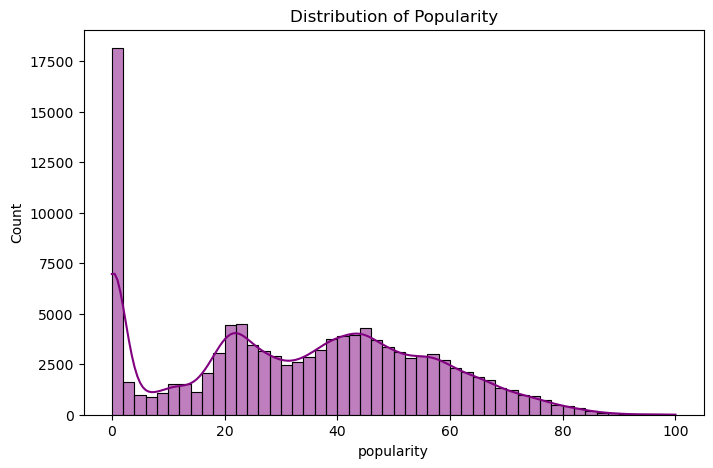

P-value   : 0.0000
Reject H₀: The popularity scores do not follow a normal distribution.


In [11]:
# Test 1: Normality of Popularity Scores

plt.figure(figsize=(8,5))
sns.histplot(df["popularity"], bins = 50, kde = True, color = "purple")
plt.title("Distribution of Popularity")
plt.show()

stat, p_value = stats.normaltest(df["popularity"])
print(f"P-value   : {p_value:.4f}")

if p_value < 0.05:
    print("Reject H₀: The popularity scores do not follow a normal distribution.")
else:
    print("Failed to reject H₀: The popularity scores may follow a normal distribution.")

Explicit vs. Non-Explicit Popularity Comparison
P-value   : 0.0000
Reject H₀: Explicit songs are more popular than non-explicit songs.


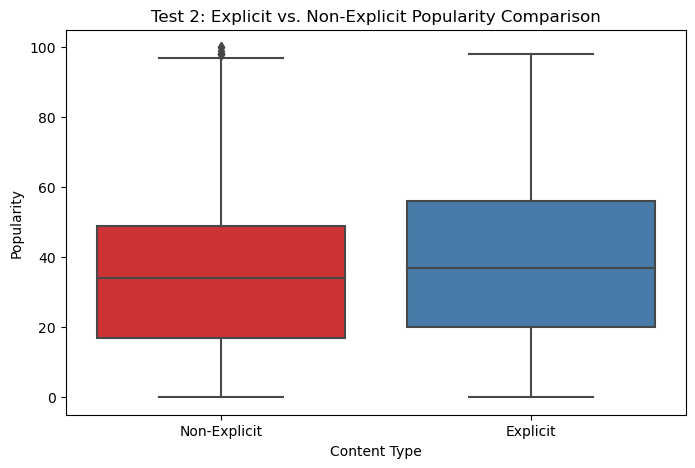

In [10]:
#Test 2: Explicit vs. Non-Explicit - Mann-Whitney U Test

explicit_popularity = df[df["explicit"] == True]["popularity"]
non_explicit_popularity = df[df["explicit"] == False]["popularity"]

stat, p_value = stats.mannwhitneyu(explicit_popularity, non_explicit_popularity, alternative='greater')

print(f"Explicit vs. Non-Explicit Popularity Comparison")
print(f"P-value   : {p_value:.4f}")

if p_value < 0.05:
    print("Reject H₀: Explicit songs are more popular than non-explicit songs.")
else:
    print("Failed to reject H₀: No significant difference in popularity between explicit and non-explicit songs.")
    

plt.figure(figsize=(8,5))
sns.boxplot(x=df["explicit"].map({True: "Explicit", False: "Non-Explicit"}), y=df["popularity"], palette="Set1")
plt.title("Test 2: Explicit vs. Non-Explicit Popularity Comparison")
plt.xlabel("Content Type")
plt.ylabel("Popularity")
plt.show()